# 02 — Modélisation CNN

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
from src.utils import load_animal_data, prepare_data, export_model, make_test_loader, ANIMAL_CLASSES, ANIMAL_INDICES, PROJECT_ROOT
from src.models.cnn import CNN
from src.models.mlp import MLP
from src.train import train_model
from src.evaluate import evaluate_model, plot_history, export_metrics
import torch

/Users/antoinegobbe/Desktop/Plateforme/neuralzoo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X_train, y_train, X_test, y_test = load_animal_data()

# Prépare les loaders
train_loader, val_loader = prepare_data(X_train, y_train, ANIMAL_INDICES)
test_loader = make_test_loader(X_test, y_test, ANIMAL_INDICES)

/Users/antoinegobbe/Desktop/Plateforme/neuralzoo/src/utils.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding='bytes')


Device : mps


Epoch 01/30 — loss: 1.5042 — val_loss: 1.4017 — val_acc: 0.4517


Epoch 02/30 — loss: 1.3730 — val_loss: 1.3595 — val_acc: 0.4720


Epoch 03/30 — loss: 1.3190 — val_loss: 1.3538 — val_acc: 0.4593


Epoch 04/30 — loss: 1.2721 — val_loss: 1.3482 — val_acc: 0.4737


...

Epoch 14/30 — loss: 0.9904 — val_loss: 1.2582 — val_acc: 0.5330


Epoch 15/30 — loss: 0.9645 — val_loss: 1.3152 — val_acc: 0.5080


Epoch 16/30 — loss: 0.9328 — val_loss: 1.2866 — val_acc: 0.5363


Epoch 17/30 — loss: 0.9158 — val_loss: 1.3628 — val_acc: 0.4980


Epoch 18/30 — loss: 0.8933 — val_loss: 1.3086 — val_acc: 0.5140
Early stopping à l'epoch 18


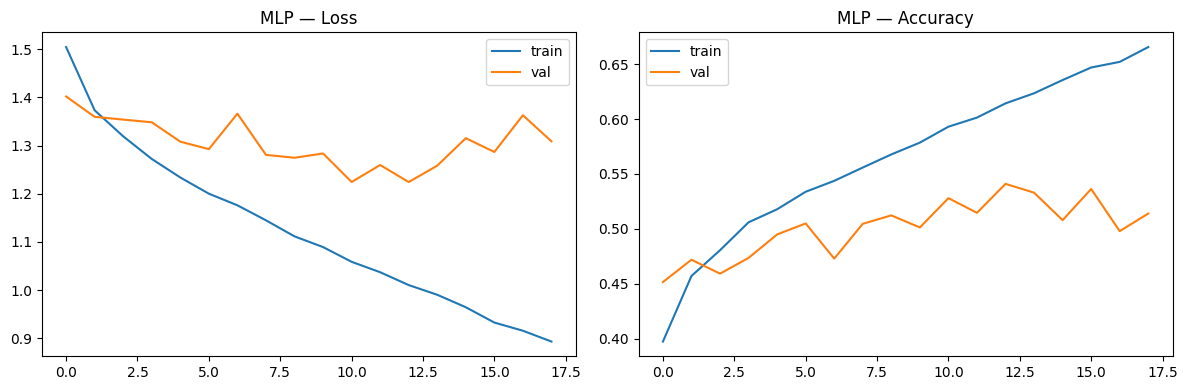

In [4]:
mlp = MLP()
history_mlp = train_model(mlp, train_loader, val_loader, epochs=30, checkpoint_name="best_mlp.pth")
plot_history(history_mlp, 'MLP')


Device : mps


Epoch 01/30 — loss: 1.4900 — val_loss: 1.2386 — val_acc: 0.5160


Epoch 02/30 — loss: 1.2825 — val_loss: 1.1150 — val_acc: 0.5687


Epoch 03/30 — loss: 1.1771 — val_loss: 1.0257 — val_acc: 0.6100


Epoch 04/30 — loss: 1.1059 — val_loss: 1.0214 — val_acc: 0.6107


...

Epoch 21/30 — loss: 0.6343 — val_loss: 0.7512 — val_acc: 0.7433


Epoch 22/30 — loss: 0.6156 — val_loss: 0.7808 — val_acc: 0.7353


Epoch 23/30 — loss: 0.6104 — val_loss: 0.7625 — val_acc: 0.7397


Epoch 24/30 — loss: 0.5969 — val_loss: 0.8561 — val_acc: 0.7150


Epoch 25/30 — loss: 0.5868 — val_loss: 0.7907 — val_acc: 0.7390
Early stopping à l'epoch 25


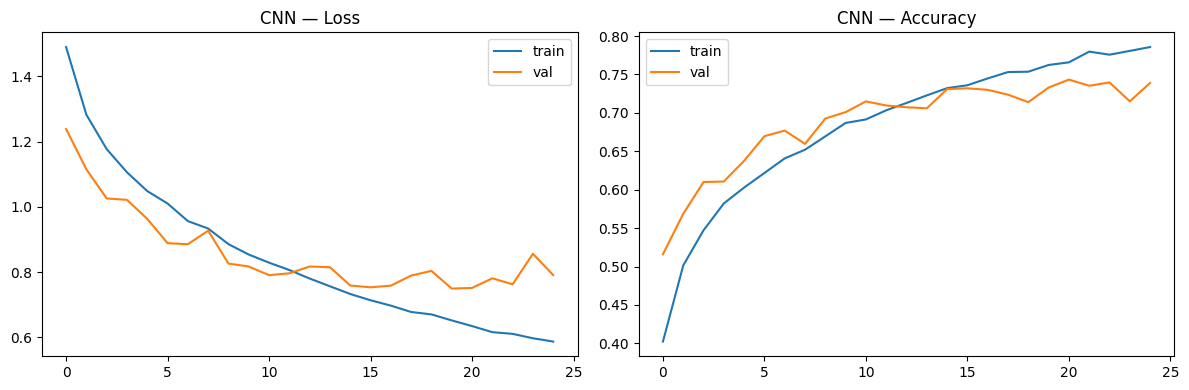

In [5]:
cnn = CNN()
history_cnn = train_model(cnn, train_loader, val_loader, epochs=30, checkpoint_name="best_cnn.pth")
plot_history(history_cnn, 'CNN')

In [6]:
cnn.load_state_dict(torch.load(PROJECT_ROOT / "models" / "best_cnn.pth", weights_only=True))

<All keys matched successfully>

              precision    recall  f1-score   support

        bird       0.71      0.76      0.73      1000
         cat       0.63      0.66      0.65      1000
        deer       0.76      0.76      0.76      1000
         dog       0.73      0.67      0.70      1000
        frog       0.84      0.82      0.83      1000
       horse       0.83      0.81      0.82      1000

    accuracy                           0.75      6000
   macro avg       0.75      0.75      0.75      6000
weighted avg       0.75      0.75      0.75      6000



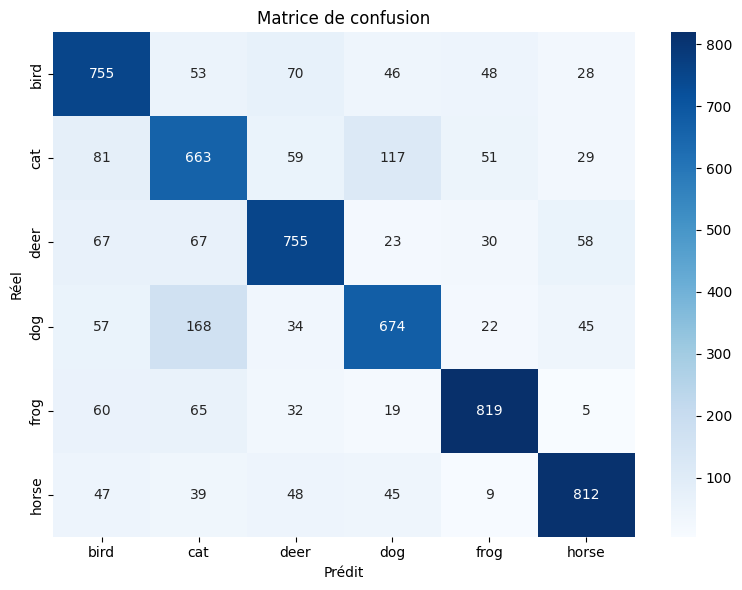

Métriques exportées → /Users/antoinegobbe/Desktop/Plateforme/neuralzoo/models/metrics.json
Modèle exporté → /Users/antoinegobbe/Desktop/Plateforme/neuralzoo/models/cnn_cifar10.pth


In [7]:
preds, labels = evaluate_model(cnn, test_loader, list(ANIMAL_CLASSES.keys()))
export_metrics(history_cnn, preds, labels, list(ANIMAL_CLASSES.keys()))
export_model(cnn)